# Fashion MNIST 이미지 분류 실습 👕👟

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.실전 대회 문제 🎯
## 1.1. 필요한 라이브러리 불러오기

In [3]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset

## 1.2.train 데이터셋 로드 및 구조 확인


In [4]:
# train 데이터 셋 로드 및 구조 확인
train_df = pd.read_csv('/content/drive/MyDrive/CV_패션의류_분류하기/fashion mnist/data/train.csv')
train_df.head()

,index,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,9,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,6,0,0,0,0,0,0,0,5,...,0,0,0,30,43,0,0,0,0,0
3,3,0,0,0,0,1,2,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,4,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 1.3. 독립변수 및 종속변수 분리와 데이터 샘플 확인

In [5]:
x_train = train_df.iloc[:, 2:]
y_train = train_df['label']

display(x_train.head(3))
display(y_train.head(3))

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0


,label
0,2
1,9
2,6


## 1.4. 처음 4개의 이미지 출력

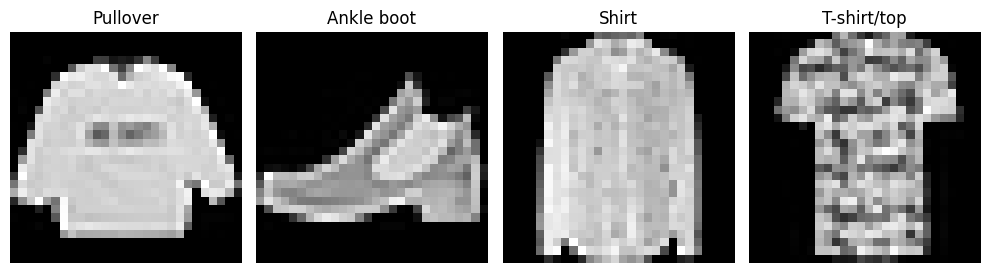

In [6]:
labels = y_train.values
images = x_train.values  # 픽셀 값만 가져옵니다

# 첫 4개의 이미지와 레이블 가져오기
num_images_to_show = 4
images_to_show = images[:num_images_to_show]
labels_to_show = labels[:num_images_to_show]

# 각 클래스의 이름
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 이미지 출력
plt.figure(figsize=(10, 4))
for i in range(num_images_to_show):
    img = images_to_show[i].reshape(28, 28)
    label = class_names[labels_to_show[i]]
    plt.subplot(1, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 1.5. 데이터셋 훈련(train) 및 검증(valid) 세트로 분할

In [7]:
x_train = x_train.values
y_train = y_train.values

x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.2, random_state=24)

print(x_train.shape)
print(x_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(48000, 784)
(12000, 784)
(48000,)
(12000,)


## 1.6. 데이터셋 형태 변환 및 차원 확인

In [8]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_valid = x_valid.reshape(x_valid.shape[0], 28, 28, 1)

print(x_train.shape)
print(x_valid.shape)

(48000, 28, 28, 1)
(12000, 28, 28, 1)


## 1.7. 이미지 데이터의 차원 순서 변경

In [9]:
x_train = x_train.transpose(0, 3, 1, 2)
x_valid = x_valid.transpose(0, 3, 1, 2)

print(x_train.shape)
print(x_valid.shape)

(48000, 1, 28, 28)
(12000, 1, 28, 28)


## 1.8. numpy 배열을 tensor로 변환

In [10]:
x_train = torch.tensor(x_train, dtype=torch.float32) / 255.0
y_train = torch.tensor(y_train, dtype=torch.long)
x_valid = torch.tensor(x_valid, dtype=torch.float32) / 255.0
y_valid = torch.tensor(y_valid, dtype=torch.long)

## 1.9. 사용자 정의 데이터셋 클래스 정의

In [11]:
class CustomDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __getitem__(self, idx):
        image = self.images[idx]

        if self.transform:
            image = self.transform(image)

        if self.labels is not None:
            label = self.labels[idx]
            return image, label
        else:
            return image

    def __len__(self):
        return len(self.images)

## 1.10. 데이터 전처리, 데이터셋 및 데이터 로더 정의

In [12]:
transform = transforms.Compose([
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = CustomDataset(x_train, y_train, transform=transform)
valid_dataset = CustomDataset(x_valid, y_valid, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

## 1.11. 간단한 CNN 모델 정의

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 1.12. 모델 학습 및 검증 함수 정의

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=2):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0

        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch'):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        train_accuracy = correct_train / len(train_loader.dataset)
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')

        model.eval()
        val_loss = 0.0
        correct_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_accuracy = correct_val / len(val_loader.dataset)
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

## 1.13. 모델 초기화 및 학습 실행

In [15]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model(model, criterion, optimizer, train_loader, valid_loader, num_epochs=2)

Epoch 1/2: 100%|██████████| 750/750 [00:07<00:00, 102.80batch/s]


Epoch 1/2, Train Loss: 0.4598, Train Accuracy: 0.8344
Validation Loss: 0.3465, Validation Accuracy: 0.8732


Epoch 2/2: 100%|██████████| 750/750 [00:06<00:00, 118.46batch/s]


Epoch 2/2, Train Loss: 0.2976, Train Accuracy: 0.8921
Validation Loss: 0.2756, Validation Accuracy: 0.8995


## 1.14. test 데이터 로드 및 데이터 로더 생성

In [16]:
test_df = pd.read_csv('/content/drive/MyDrive/CV_패션의류_분류하기/fashion mnist/data/test.csv')
x_test = test_df.iloc[:, 1:].values

x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).transpose(0, 3, 1, 2)
x_test = torch.tensor(x_test, dtype=torch.float32)

test_dataset = CustomDataset(x_test, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 1.15.test 데이터에 대한 예측 수행

In [17]:
model.eval()
predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        predictions.extend(preds.cpu().numpy())

predictions[:10]

[np.int64(0),
 np.int64(1),
 np.int64(6),
 np.int64(6),
 np.int64(3),
 np.int64(6),
 np.int64(8),
 np.int64(6),
 np.int64(5),
 np.int64(0)]

## 1.16. 예측 결과를 제출 파일로 저장

In [18]:
submission = pd.read_csv('/content/drive/MyDrive/CV_패션의류_분류하기/fashion mnist/data/sample_submission.csv')

submission['label'] = predictions
submission.to_csv('submission.csv', index=False)